In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [6]:
# Load the dataset


logging.info("Loading the dataset.")
data_path = "../data/merged_train_data.parquet"  # Update with your actual file path

# Use read_parquet for .parquet files
try:
    data = pd.read_parquet(data_path)
    logging.info("Dataset loaded successfully. Displaying basic information:")
    print(data.info())
    print(data.head())
except Exception as e:
    logging.error("Error loading the dataset: %s", e)
    raise e


2025-01-09 18:53:07,075 - INFO - Loading the dataset.
2025-01-09 18:53:07,591 - INFO - Dataset loaded successfully. Displaying basic information:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               986159 non-null   float64
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionO

In [7]:

# Setting up logging
logging.basicConfig(level=logging.INFO)

# Convert Date column to datetime format
logging.info("Converting 'Date' column to datetime.")
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Check if the conversion was successful
logging.info("Checking for missing values after Date conversion.")
logging.info(f"Missing values in 'Date': {data['Date'].isnull().sum()}")

# Handle missing values for 'StateHoliday' - you can use the mode (most frequent value) or fill with 0 if it makes sense
logging.info("Filling missing values in 'StateHoliday'.")
data['StateHoliday'] = data['StateHoliday'].fillna(0)

# Handle missing values for 'PromoInterval' - you can fill with 'None' if it makes sense
logging.info("Filling missing values in 'PromoInterval'.")
data['PromoInterval'] = data['PromoInterval'].fillna('None')

# Verify changes
logging.info("Verifying missing values after filling.")
logging.info(f"Missing values in 'StateHoliday': {data['StateHoliday'].isnull().sum()}")
logging.info(f"Missing values in 'PromoInterval': {data['PromoInterval'].isnull().sum()}")


2025-01-09 18:53:08,320 - INFO - Converting 'Date' column to datetime.
2025-01-09 18:53:08,627 - INFO - Checking for missing values after Date conversion.
2025-01-09 18:53:08,635 - INFO - Missing values in 'Date': 0
2025-01-09 18:53:08,639 - INFO - Filling missing values in 'StateHoliday'.
2025-01-09 18:53:08,668 - INFO - Filling missing values in 'PromoInterval'.
2025-01-09 18:53:09,003 - INFO - Verifying missing values after filling.
2025-01-09 18:53:09,017 - INFO - Missing values in 'StateHoliday': 0
2025-01-09 18:53:09,173 - INFO - Missing values in 'PromoInterval': 0


In [8]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Extract weekday and weekend information
logging.info("Extracting weekday and weekend information.")
data['Weekday'] = data['Date'].dt.weekday  # Monday=0, Sunday=6
data['Is_Weekend'] = data['Weekday'].isin([5, 6]).astype(int)  # 1 if weekend, 0 otherwise

# Step 2: Generate Days_To_Holiday and Days_After_Holiday
# Note: This part assumes you have a predefined list of holidays, like 'holidays = [pd.Timestamp('YYYY-MM-DD')]'
holidays = pd.to_datetime(['2015-12-25', '2016-01-01', '2016-12-25'])  # example holidays

logging.info("Calculating 'Days_To_Holiday' and 'Days_After_Holiday'.")
data['Days_To_Holiday'] = data['Date'].apply(
    lambda x: min([(holiday - x).days for holiday in holidays if (holiday - x).days > 0], default=np.nan)
)
data['Days_After_Holiday'] = data['Date'].apply(
    lambda x: min([(x - holiday).days for holiday in holidays if (x - holiday).days > 0], default=np.nan)
)

# Step 3: Create features for beginning, mid-month, and end-of-month
logging.info("Creating features for the beginning, mid-month, and end-of-month.")
data['Day_Of_Month'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

data['Beginning_Of_Month'] = (data['Day_Of_Month'] <= 7).astype(int)
data['Mid_Month'] = ((data['Day_Of_Month'] > 7) & (data['Day_Of_Month'] <= 14)).astype(int)
data['End_Of_Month'] = (data['Day_Of_Month'] > 14).astype(int)

# Step 4: Apply feature scaling using StandardScaler
logging.info("Scaling numeric features using StandardScaler.")
numeric_features = ['Sales', 'Customers', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 
                    'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'Days_To_Holiday', 
                    'Days_After_Holiday', 'Day_Of_Month', 'Month', 'Year']

scaler = StandardScaler()
data[numeric_features] = scaler.fit_transform(data[numeric_features])

# Verify the first few rows of the preprocessed dataset
logging.info("Displaying the first few rows of the preprocessed dataset.")
print(data.head())



2025-01-09 18:53:09,208 - INFO - Extracting weekday and weekend information.


2025-01-09 18:53:09,503 - INFO - Calculating 'Days_To_Holiday' and 'Days_After_Holiday'.


KeyboardInterrupt: 

In [4]:


logging.basicConfig(level=logging.INFO)

# Load the dataset
data_path = "../data/merged_train_data.parquet"  # Update this path accordingly
data = pd.read_parquet(data_path)  # Adjust depending on the file format

# Ensure the dataset is loaded correctly
logging.info(f"Dataset loaded. Shape: {data.shape}")
logging.info(f"Columns: {data.columns.tolist()}")

# Fill missing values if any
data['StateHoliday'].fillna(0, inplace=True)
data['PromoInterval'].fillna('None', inplace=True)

# Convert date columns to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Feature Engineering: Day of the week, weekend flag
data['Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Adding additional temporal features
data['Days_To_Holiday'] = (data['Date'] - pd.to_datetime('2025-12-25')).dt.days  # Example for holidays, modify as needed
data['Days_After_Holiday'] = (pd.to_datetime('2025-12-25') - data['Date']).dt.days

# Extract day, month, and year as features
data['Day_Of_Month'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# Example: StoreType conversion to categorical
data['StoreType'] = data['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})  # Map store types to numerical values

# Check transformed data
logging.info(f"Transformed data preview:\n{data.head()}")


INFO:root:Dataset loaded. Shape: (1017209, 18)
INFO:root:Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
C:\Users\Hp\AppData\Local\Temp\ipykernel_14248\3914496272.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['StateHoliday'].fillna(0, inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipyk

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns with LabelEncoder
label_encoder = LabelEncoder()

# Convert 'StoreType', 'Assortment', 'PromoInterval' to numeric
data['StoreType'] = label_encoder.fit_transform(data['StoreType'])
data['Assortment'] = label_encoder.fit_transform(data['Assortment'])
data['PromoInterval'] = data['PromoInterval'].fillna('None')  # Fill missing values with 'None' for PromoInterval
data['PromoInterval'] = label_encoder.fit_transform(data['PromoInterval'])

# Ensure the columns are now numeric
logging.info(f"Encoded categorical columns. Preview:\n{data[['StoreType', 'Assortment', 'PromoInterval']].head()}")


INFO:root:Encoded categorical columns. Preview:
   StoreType  Assortment  PromoInterval
0          2           0              3
1          0           0              1
2          0           0              1
3          2           2              3
4          0           0              3


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import numpy as np

# Load the dataset
data_path = "../data/merged_train_data.parquet"  # Update this path accordingly
data = pd.read_parquet(data_path)

# Define features (X) and target (y)
X = data.drop(columns=['Sales'])  # Ensure the correct column name 'Sales'
y = data['Sales']

# Check for non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_columns}")

# Encode non-numeric columns
label_encoders = {}
for col in non_numeric_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # Convert to string before encoding
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Ensure all remaining features are numeric and handle missing values
X = X.apply(pd.to_numeric, errors='coerce')  # Convert to numeric where possible
X = X.fillna(0)  # Replace NaN values with 0

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R-Squared (R²): {r2}")


Non-numeric columns: Index(['Date', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')
Encoded column: Date
Encoded column: StoreType
Encoded column: Assortment
Encoded column: PromoInterval
R-Squared (R²): 0.9862912124085434


In [9]:
print("Columns in the DataFrame:", data.columns)


Columns in the DataFrame: Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import logging 


logging.info("MAE")
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


2025-01-09 01:48:23,194 - INFO - MAE


Mean Absolute Error (MAE): 270.98245367229975
Root Mean Squared Error (RMSE): 450.2626627359955


In [10]:
import pandas as pd

# Create predictions_df
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})


In [17]:
import os
error_analysis = predictions_df.copy()
predictions_df['Error'] = predictions_df['Actual'] - predictions_df['Predicted']

error_analysis['Error'] = abs(error_analysis['Actual'] - error_analysis['Predicted'])
error_analysis = error_analysis.sort_values(by='Error', ascending=False)
print(error_analysis.head())

output_folder = 'notebooks/outputs'
os.makedirs(output_folder, exist_ok=True)

# Save predictions
predictions_path = os.path.join(output_folder, 'predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to {predictions_path}")

# Save error analysis
error_analysis_path = os.path.join(output_folder, 'error_analysis.csv')
error_analysis.to_csv(error_analysis_path, index=False)
print(f"Error analysis saved to {error_analysis_path}")



        Actual  Predicted     Error
44393    41551   18752.75  22798.25
684721   17298    3521.66  13776.34
692526   16558    3121.01  13436.99
693985   18697    5659.00  13038.00
454398   25920   13689.44  12230.56
Predictions saved to notebooks/outputs\predictions.csv
Error analysis saved to notebooks/outputs\error_analysis.csv


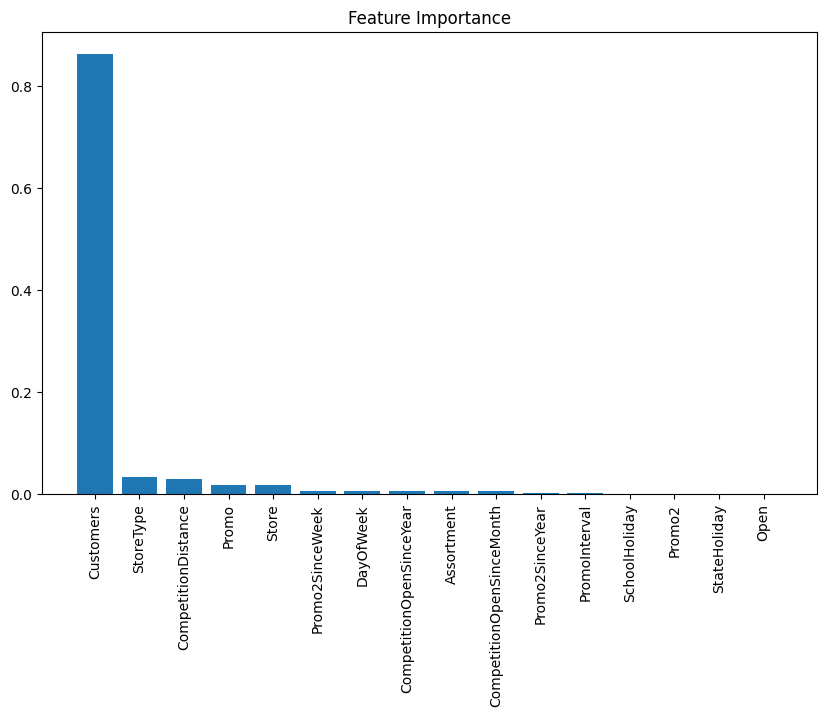

<Figure size 640x480 with 0 Axes>

In [13]:

logging.info("feauter importance")
feature_importances = model.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), X.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.show()

output_folder = './outputs'
os.makedirs(output_folder, exist_ok=True)
feature_importance_path = os.path.join(output_folder, 'feature_importance.png')
plt.savefig(feature_importance_path)



Plot Details:
Type: Residuals Plot (Scatter plot of Actual vs. Prediction Error)
X-axis Label: Actual Values
Y-axis Label: Prediction Error
Title: Residuals Plot
Residuals plot saved to notebooks/outputs\residuals_plot.png


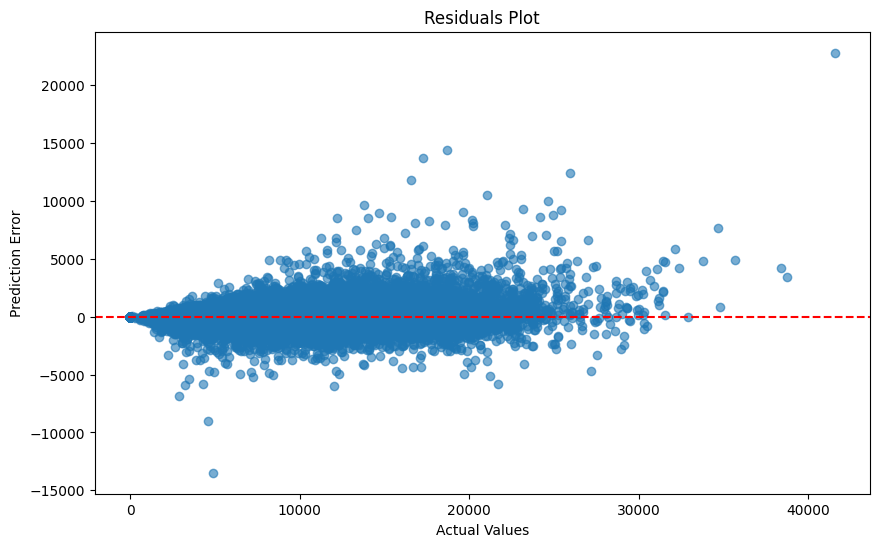

In [18]:
# Residuals Plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions_df['Actual'], predictions_df['Error'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Prediction Error')
plt.title('Residuals Plot')

# Log plot details
print("Plot Details:")
print("Type: Residuals Plot (Scatter plot of Actual vs. Prediction Error)")
print(f"X-axis Label: Actual Values")
print(f"Y-axis Label: Prediction Error")
print(f"Title: Residuals Plot")

# Save the plot
residual_plot_path = os.path.join(output_folder, 'residuals_plot.png')
plt.savefig(residual_plot_path)
print(f"Residuals plot saved to {residual_plot_path}")

# Show the plot
plt.show()


In [14]:
print(predictions_df.head())
print(predictions_df.columns)


        Actual  Predicted
76435        0       0.00
923026    5548    5654.28
731180    7467    7586.23
790350    3360    3471.71
252134   11414    9457.95
Index(['Actual', 'Predicted'], dtype='object')


In [21]:

from sklearn.metrics import mean_squared_error

# Custom function for Huber Loss
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = abs(error) <= delta
    squared_loss = 0.5 * error**2
    linear_loss = delta * (abs(error) - 0.5 * delta)
    return np.where(is_small_error, squared_loss, linear_loss).mean()

# Calculate Huber Loss
huber = huber_loss(predictions_df['Actual'].values, predictions_df['Predicted'].values, delta=1.0)
logging.info(f"Huber Loss: {huber}")
print(f"Huber Loss: {huber}")


2025-01-06 17:29:19,925 - INFO - Huber Loss: 270.56796656172276


Huber Loss: 270.56796656172276


In [23]:
# Define the summary content
summary = (
    f"Loss Function Results:\n"
    f"- Huber Loss: {huber_loss}\n"
    f"- Explanation: Huber Loss is chosen because it balances sensitivity to large errors "
    f"while being robust to outliers, making it ideal for sales data.\n"
)


In [24]:
# Save loss results to file
loss_results_path = os.path.join(output_folder, 'loss_function_results.txt')
with open(loss_results_path, 'w') as file:
    file.write(summary)

logging.info(f"Loss function results saved to {loss_results_path}")
print(f"Loss function results saved to {loss_results_path}")


2025-01-06 17:32:59,786 - INFO - Loss function results saved to notebooks/outputs\loss_function_results.txt


Loss function results saved to notebooks/outputs\loss_function_results.txt


C:\Users\Hp\AppData\Local\Temp\ipykernel_2660\2413839759.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


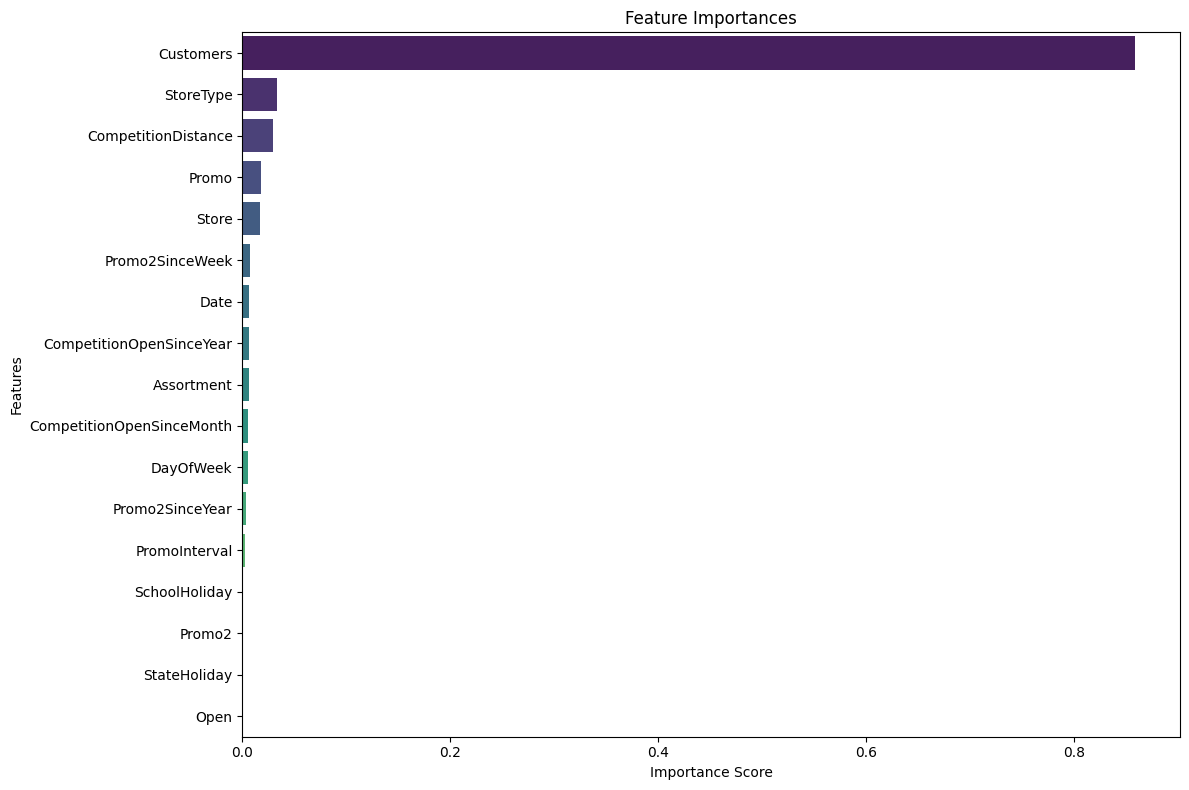

2025-01-09 02:23:25,212 - INFO - Feature importances plot saved to notebooks/outputs\feature_importances_plot.png


Feature importances plot saved to notebooks/outputs\feature_importances_plot.png


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(
    x=feature_importances_df['Importance'], 
    y=feature_importances_df['Feature'], 
    palette='viridis'
)
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()

# Save the plot
feature_importances_plot_path = os.path.join(output_folder, 'feature_importances_plot.png')
plt.savefig(feature_importances_plot_path)
plt.show()

logging.info(f"Feature importances plot saved to {feature_importances_plot_path}")
print(f"Feature importances plot saved to {feature_importances_plot_path}")


In [30]:
# Calculate residuals
predictions_df['Residuals'] = predictions_df['Actual'] - predictions_df['Predicted']

# Compute residual statistics
residual_mean = predictions_df['Residuals'].mean()
residual_std = predictions_df['Residuals'].std()

print(f"Residual Mean: {residual_mean}")
print(f"Residual Standard Deviation: {residual_std}")

logging.info(f"Residual Mean: {residual_mean}")
logging.info(f"Residual Standard Deviation: {residual_std}")


2025-01-09 02:24:45,668 - INFO - Residual Mean: 5.955159996460906
2025-01-09 02:24:45,670 - INFO - Residual Standard Deviation: 450.2243861521881


Residual Mean: 5.955159996460906
Residual Standard Deviation: 450.2243861521881


In [31]:
from scipy.stats import norm

# Define confidence level
confidence_level = 0.95
z_score = norm.ppf((1 + confidence_level) / 2)

# Compute margins
margin_of_error = z_score * residual_std

# Add confidence intervals to predictions
predictions_df['Lower Bound'] = predictions_df['Predicted'] - margin_of_error
predictions_df['Upper Bound'] = predictions_df['Predicted'] + margin_of_error

# Save updated predictions
confidence_intervals_path = os.path.join(output_folder, 'predictions_with_confidence_intervals.csv')
predictions_df.to_csv(confidence_intervals_path, index=False)

print(f"Confidence intervals added and saved to {confidence_intervals_path}")
logging.info(f"Confidence intervals added and saved to {confidence_intervals_path}")


2025-01-09 02:25:00,463 - INFO - Confidence intervals added and saved to notebooks/outputs\predictions_with_confidence_intervals.csv


Confidence intervals added and saved to notebooks/outputs\predictions_with_confidence_intervals.csv


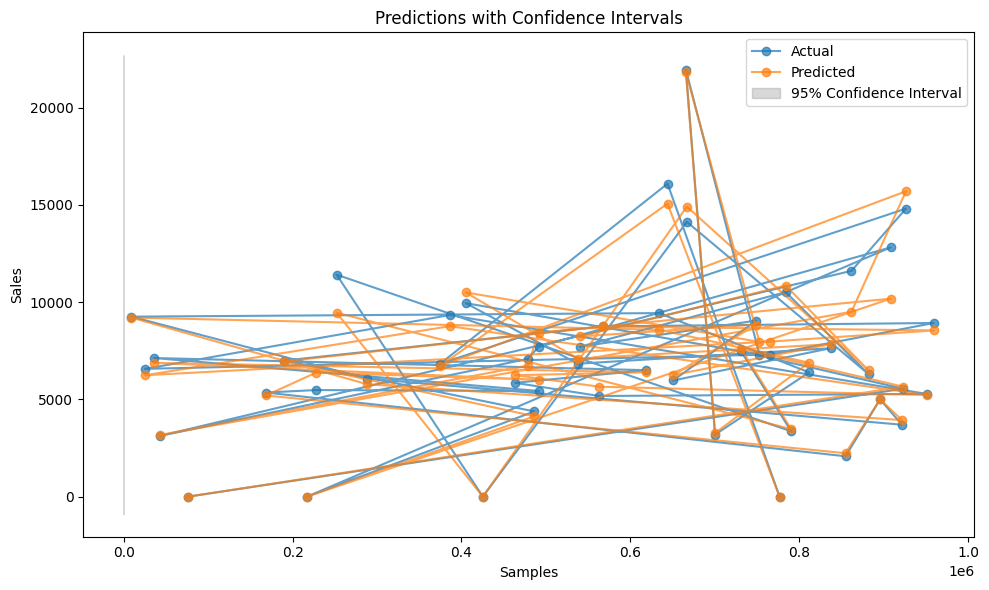

2025-01-09 02:25:19,761 - INFO - Confidence intervals plot saved to notebooks/outputs\confidence_intervals_plot.png


Confidence intervals plot saved to notebooks/outputs\confidence_intervals_plot.png


In [32]:
plt.figure(figsize=(10, 6))
plt.plot(predictions_df['Actual'][:50], label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(predictions_df['Predicted'][:50], label='Predicted', marker='o', linestyle='-', alpha=0.7)
plt.fill_between(
    x=range(len(predictions_df[:50])), 
    y1=predictions_df['Lower Bound'][:50], 
    y2=predictions_df['Upper Bound'][:50], 
    color='gray', alpha=0.3, label='95% Confidence Interval'
)
plt.xlabel('Samples')
plt.ylabel('Sales')
plt.title('Predictions with Confidence Intervals')
plt.legend()
plt.tight_layout()

# Save the plot
confidence_intervals_plot_path = os.path.join(output_folder, 'confidence_intervals_plot.png')
plt.savefig(confidence_intervals_plot_path)
plt.show()

logging.info(f"Confidence intervals plot saved to {confidence_intervals_plot_path}")
print(f"Confidence intervals plot saved to {confidence_intervals_plot_path}")


In [13]:
import os
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Calculate residuals
predictions_df['Residuals'] = predictions_df['Actual'] - predictions_df['Predicted']

# Compute residual statistics
residual_mean = predictions_df['Residuals'].mean()
residual_std = predictions_df['Residuals'].std()

# Log and display residual statistics
residual_mean, residual_std

# Define confidence level
confidence_level = 0.95
z_score = norm.ppf((1 + confidence_level) / 2)

# Compute margins
margin_of_error = z_score * residual_std

# Add confidence intervals to predictions
predictions_df['Lower Bound'] = predictions_df['Predicted'] - margin_of_error
predictions_df['Upper Bound'] = predictions_df['Predicted'] + margin_of_error

# Save updated predictions
confidence_intervals_path = os.path.join(output_folder, 'predictions_with_confidence_intervals.csv')
predictions_df.to_csv(confidence_intervals_path, index=False)

confidence_intervals_path


'notebooks/outputs\\predictions_with_confidence_intervals.csv'

In [14]:
import joblib
from datetime import datetime
import os
import logging

timestamp = datetime.now().strftime('%Y-%m-%d-%H-%M-%S-00')
model_filename = f"model-{timestamp}.pkl"
print(f"Generated filename: {model_filename}")


serialized_models_dir = os.path.join("notebooks", "outputs", "serialized_models")
os.makedirs(serialized_models_dir, exist_ok=True)
print(f"Models will be saved to: {serialized_models_dir}")

model_path = os.path.join(serialized_models_dir, model_filename)
joblib.dump(random_forest_model, model_path)
print(f"Model serialized and saved to: {model_path}")



logging.info(f"Model serialized and saved to: {model_path}")



Generated filename: model-2025-01-10-00-47-58-00.pkl
Models will be saved to: notebooks\outputs\serialized_models


NameError: name 'random_forest_model' is not defined

In [18]:
import joblib
import os
from datetime import datetime

serialized_models_dir = os.path.join("notebooks", "outputs", "serialized_models")
os.makedirs(serialized_models_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y-%m-%d-%H-%M-%S-00')
model_filename = f"random_forest_model-{timestamp}.pkl"

# Save the trained model
model_path = os.path.join(serialized_models_dir, model_filename)
joblib.dump(model, model_path)

print(f"Model serialized and saved to: {model_path}")



Model serialized and saved to: notebooks\outputs\serialized_models\random_forest_model-2025-01-10-00-51-54-00.pkl
